# **New York City Yellow Taxi Data**

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings

import warnings

In [3]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [9]:
# Try loading one file

df = pd.read_parquet('2023-1.parquet')
df.info()
df = pd.read_parquet('2023-1.parquet')
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [10]:
# checking the 5 rows of df
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [11]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/EDA_NYC_TAXI/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        monthly_data = pd.read_parquet(file_path)
        # convert 'tpep_pickup_datetime' to datetime column
        monthly_data['tpep_pickup_datetime'] = pd.to_datetime(monthly_data['tpep_pickup_datetime'])

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in monthly_data['tpep_pickup_datetime'].dt.date.unique():
            daily_data = monthly_data[monthly_data['tpep_pickup_datetime'].dt.date == date]


            # Iterate through each hour of the selected date
            for hours in range(24):
                hourly_data = daily_data[daily_data['tpep_pickup_datetime'].dt.hour == hours]


                # Sample 5% of the hourly data randomly
                sample = hourly_data.sample(frac=0.02, random_state=42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data,sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df,sampled_data])
        # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [12]:
# Store the df in csv/parquet
df.to_parquet('df.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [13]:
# Load the new data file

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3188075,2,2023-12-31 21:21:53,2023-12-31 21:35:28,2.0,3.69,1.0,N,107,262,1,17.70,1.0,0.5,5.67,0.0,1.0,28.37,2.5,NaN,0.00
3192997,2,2023-12-31 22:36:14,2023-12-31 22:39:09,1.0,0.41,1.0,N,41,151,2,5.10,1.0,0.5,0.00,0.0,1.0,7.60,0.0,NaN,0.00
3189566,2,2023-12-31 22:54:43,2023-12-31 23:05:26,2.0,1.43,1.0,N,237,239,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,NaN,0.00
3196366,2,2023-12-31 23:53:18,2024-01-01 00:10:03,1.0,3.08,1.0,N,50,107,1,18.40,1.0,0.5,5.00,0.0,1.0,28.40,2.5,NaN,0.00


In [14]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [15]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773689 entries, 428 to 3194193
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               773689 non-null  int64         
 1   tpep_pickup_datetime   773689 non-null  datetime64[us]
 2   tpep_dropoff_datetime  773689 non-null  datetime64[us]
 3   passenger_count        747554 non-null  float64       
 4   trip_distance          773689 non-null  float64       
 5   RatecodeID             747554 non-null  float64       
 6   store_and_fwd_flag     747554 non-null  object        
 7   PULocationID           773689 non-null  int64         
 8   DOLocationID           773689 non-null  int64         
 9   payment_type           773689 non-null  int64         
 10  fare_amount            773689 non-null  float64       
 11  extra                  773689 non-null  float64       
 12  mta_tax                773689 non-null  float6

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [16]:
# Fix the index and drop any columns that are not needed
# droping old index column
df.reset_index(drop= True,inplace= True)
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [17]:
# first check the missing values
df.isnull().sum().sort_values(ascending=False)*100/len(df)

,0
airport_fee,92.164293
Airport_fee,11.213679
passenger_count,3.377972
RatecodeID,3.377972
congestion_surcharge,3.377972
store_and_fwd_flag,3.377972
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
DOLocationID,0.000000


In [18]:
# Combine the two airport fee columns
 # replacing missing values in 'Airport_fee' and 'airport_fee' with mode bcause most rides are non airport trips
df['Airport_fee'].fillna(df['Airport_fee'].mode()[0],inplace=True)
df['airport_fee'].fillna(df['airport_fee'].mode()[0],inplace=True)

/tmp/ipython-input-3667371960.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Airport_fee'].fillna(df['Airport_fee'].mode()[0],inplace=True)
/tmp/ipython-input-3667371960.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [19]:
# droping 'Airport_fee' column ,not has no use
df.drop('Airport_fee', axis=1,inplace=True)

In [20]:
# checking columns
df.isna().sum().sort_index(ascending= True)

,0
DOLocationID,0
PULocationID,0
RatecodeID,26135
VendorID,0
airport_fee,0
congestion_surcharge,26135
extra,0
fare_amount,0
improvement_surcharge,0
mta_tax,0


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [21]:
# check where values of fare amount are negative
negative_values= df[df['fare_amount']<0]
negative_values
# no negative values in 'fare_amount'

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [22]:
# Analyse RatecodeID for the negative fare amounts
Ratecode_analyses = df[df['fare_amount']<0]['RatecodeID'].value_counts()
Ratecode_analyses


,count
RatecodeID,


In [23]:
# Find which columns have negative values

negative_col= [col for col in df.select_dtypes(['Int64','float64']) if (df[col]<0).any()]
negative_col


['extra',
 'mta_tax',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

In [24]:
# we will check value counts for these negative value column
negative_counts={}
for col in negative_col:
  if (df[col]<0).any():
    negative_counts[col] = int(df[df[col]<0][col].count())
negative_counts

{'extra': 2,
 'mta_tax': 37,
 'improvement_surcharge': 39,
 'total_amount': 39,
 'congestion_surcharge': 30,
 'airport_fee': 1}

In [25]:
# fix these negative values
# as we can see with the help of value couts that negative values are less which is(1.8%) so we can drop those values
total= sum(negative_counts.values())
total
print(total*100/len(df))

# now we will drop these values

df.drop(df[(df[negative_col]<0).any(axis=1)].index,inplace=True)



0.019129133282236144


In [26]:
# confirming that all negatives values are removed
(df[negative_col]<0).sum()

,0
extra,0
mta_tax,0
improvement_surcharge,0
total_amount,0
congestion_surcharge,0
airport_fee,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [27]:
# Find the proportion of missing values in each column
missing_values = df.isna().sum().sort_values(ascending=False)*100/len(df)
missing_values

,0
store_and_fwd_flag,3.378147
RatecodeID,3.378147
passenger_count,3.378147
congestion_surcharge,3.378147
tpep_dropoff_datetime,0.000000
VendorID,0.000000
tpep_pickup_datetime,0.000000
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [28]:
# Display the rows with null values
df[df.isna().any(axis=1)]
# Impute NaN values in 'passenger_count'


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.00,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.00,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.00,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.00,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.00,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773585,1,2023-12-28 20:52:04,2023-12-28 21:01:52,NaN,1.50,NaN,None,164,158,0,10.70,1.00,0.5,2.36,0.00,1.0,18.06,NaN,0.0
773619,2,2023-12-29 21:18:26,2023-12-29 21:37:17,NaN,5.70,NaN,None,161,88,0,33.69,0.00,0.5,7.54,0.00,1.0,45.23,NaN,0.0
773634,2,2023-12-30 12:42:09,2023-12-30 12:51:20,NaN,1.26,NaN,None,141,43,0,11.74,0.00,0.5,3.15,0.00,1.0,18.89,NaN,0.0
773644,1,2023-12-30 17:48:45,2023-12-30 18:13:22,NaN,8.30,NaN,None,138,164,0,35.20,6.75,0.5,10.58,6.94,1.0,63.47,NaN,0.0


In [29]:
# Impute NaN values in 'passenger_count'
df['passenger_count'].value_counts()
# passenger_count is discreate numerical column so we will replace missing values with most frequesnt values  or mode that is 1.0
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

/tmp/ipython-input-71482071.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)


In [30]:
df['passenger_count'].value_counts(normalize=True)
# As we can see with passenger_count column there are around 1.5% data is for 0.0 passenger ,it's a mistake .let's replace it with mode
df['passenger_count'].replace(0.0,1.0,inplace=True)

/tmp/ipython-input-2366225937.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].replace(0.0,1.0,inplace=True)


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [31]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].value_counts()
# it's a categorical nominal column so we will replace missing values with mode
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0],inplace = True)

/tmp/ipython-input-1670490218.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].fillna(df['RatecodeID'].mode()[0],inplace = True)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [32]:
# handle null values in congestion_surcharge
df['congestion_surcharge'].value_counts()
# this is continuous numerical column so we will replace nan values with median because data is skewed.
df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(),inplace=True)

/tmp/ipython-input-2598254394.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(),inplace=True)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [33]:
# Handle any remaining missing values

df.isna().sum()
# store_and_fwd_flag' also has missing values
df['store_and_fwd_flag'].value_counts()
# it is categorical nominal column so we will replace it with mode
# but it seems like column 'store_and_fwd_flag' has no longer use in future for eda analysis
# so we will drop this column
df.drop(columns=['store_and_fwd_flag'], inplace= True)

In [34]:
# checking for missing values
df.isna().sum()
# no missing values are remaining.

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

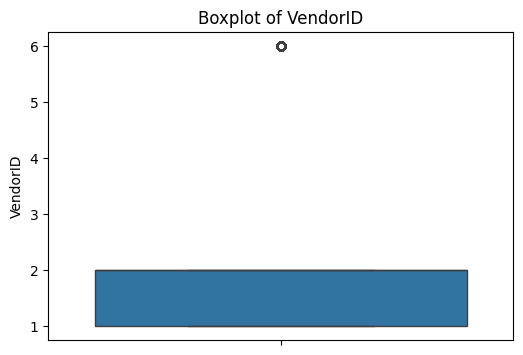

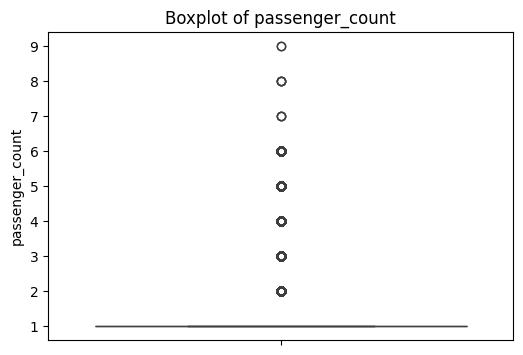

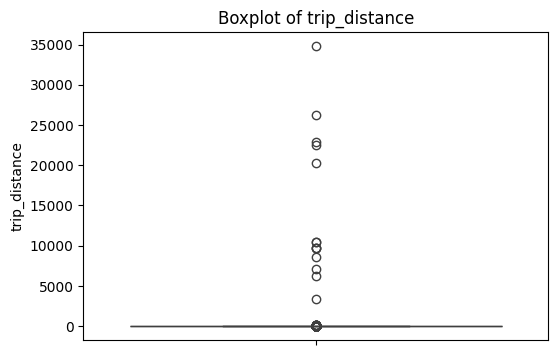

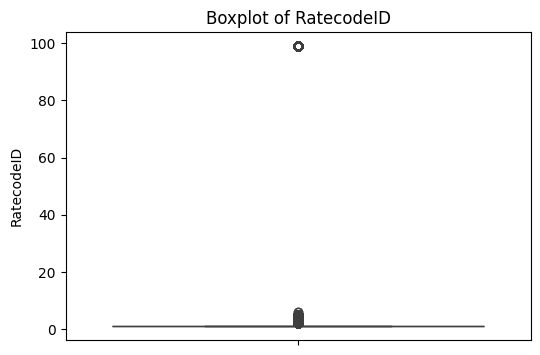

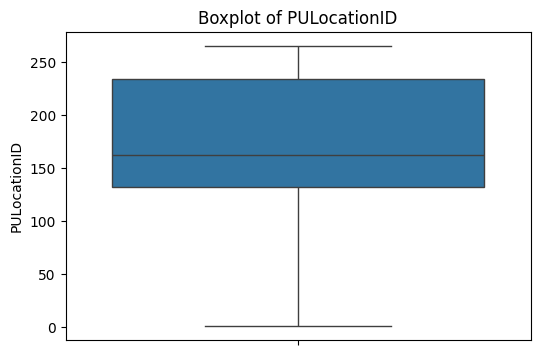

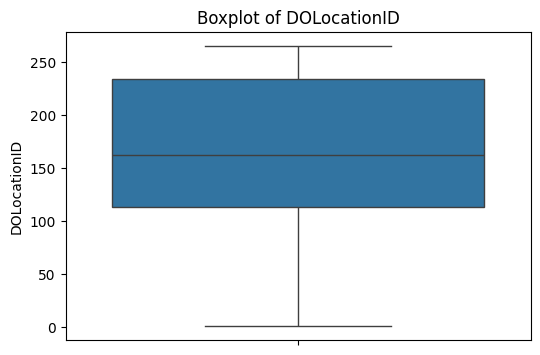

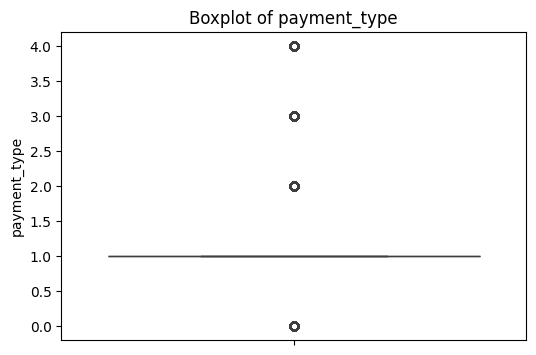

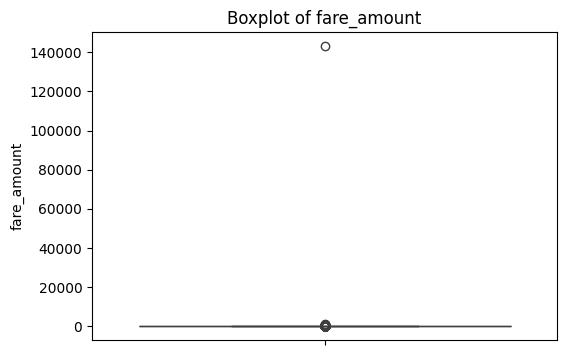

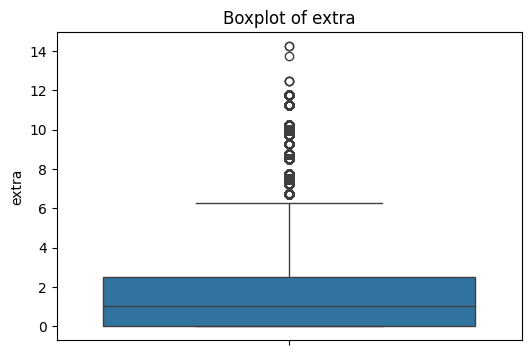

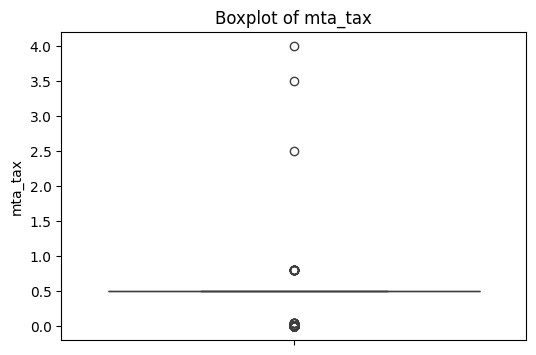

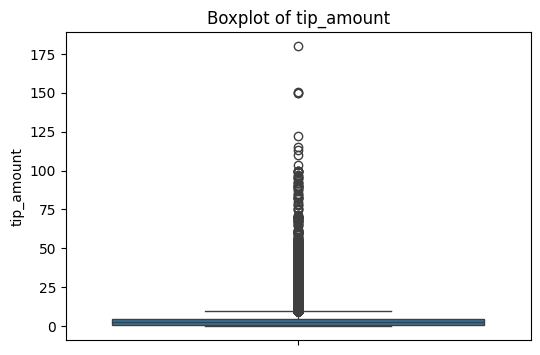

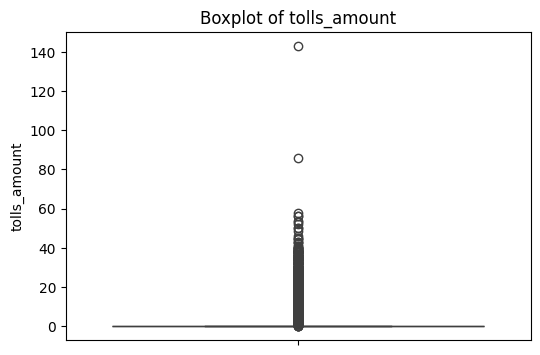

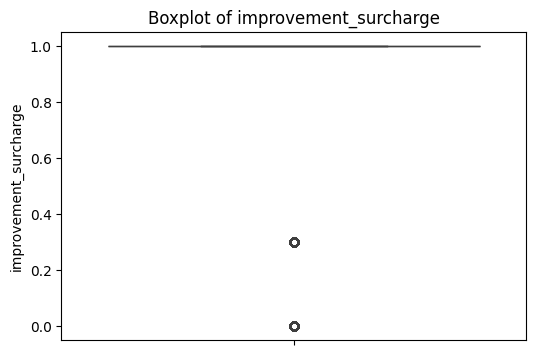

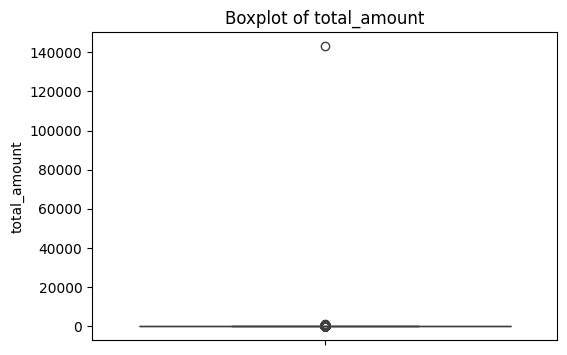

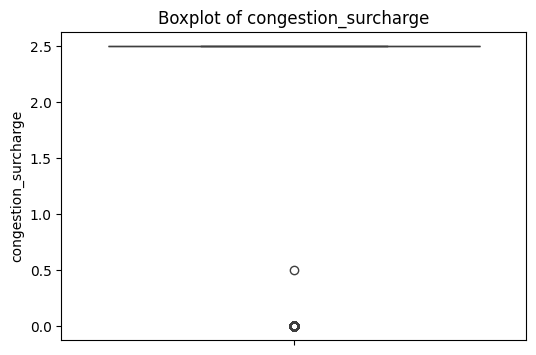

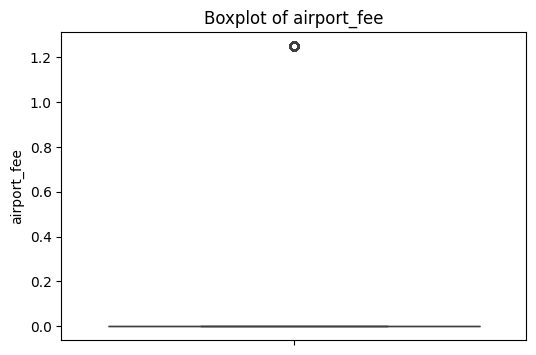

In [35]:

# Describe the data and check if there are any potential outliers present
df.describe()

# Check for potential out of place values in various columns
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(data= df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [36]:
# we will perform IQR test for outliers dectection
outliers_dict={}
for col in numeric_columns:
  Q1= df[col].quantile(0.25)
  Q2= df[col].quantile(0.75)
  IQR =  Q2-Q1
  upper_bound= Q2+1.5*IQR
  lower_bound= Q1-1.5*IQR
  outliers_count= df[(df[col]<lower_bound)|(df[col]>upper_bound)][col].count()
  outliers_dict[col]= outliers_count
outliers_dict

{'VendorID': np.int64(186),
 'passenger_count': np.int64(172925),
 'trip_distance': np.int64(101373),
 'RatecodeID': np.int64(41793),
 'PULocationID': np.int64(0),
 'DOLocationID': np.int64(0),
 'payment_type': np.int64(164591),
 'fare_amount': np.int64(80312),
 'extra': np.int64(13669),
 'mta_tax': np.int64(7299),
 'tip_amount': np.int64(59108),
 'tolls_amount': np.int64(62390),
 'improvement_surcharge': np.int64(889),
 'total_amount': np.int64(89295),
 'congestion_surcharge': np.int64(57600),
 'airport_fee': np.int64(5347)}

In [37]:
# remove passenger_count > 6
df.drop(df[df['passenger_count']>6].index,inplace=True)


In [38]:
# Continue with outlier handling
# as per the above analyses:

#  we will drop Entries where trip_distance is nearly 0 and fare_amount is more than 300
df.drop(df[(df['trip_distance']==0) & (df['fare_amount']>300)].index,inplace=True)

# drop entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different
df.drop(df[(df['trip_distance']==0)&(df['fare_amount']==0)&(df['PULocationID']!=df['DOLocationID'])].index,inplace=True)

# drop Entries where trip_distance is more than 250 miles.
df.drop(df[df['trip_distance']>250].index,inplace=True)

# drop Entries where payment_type is 0
df.drop(df[df['payment_type']==0].index,inplace=True)



In [39]:
# checking value counts for each column to check any outlier variable in df
for col in numeric_columns.columns:
  print(df[col].value_counts())

VendorID
2    550753
1    196705
Name: count, dtype: int64
passenger_count
1.0    574553
2.0    113005
3.0     28086
4.0     15551
5.0      9771
6.0      6492
Name: count, dtype: int64
trip_distance
0.90     10391
1.00     10289
0.80     10094
1.10     10066
1.20      9955
         ...  
27.18        1
41.00        1
38.13        1
23.49        1
68.14        1
Name: count, Length: 3436, dtype: int64
RatecodeID
1.0     705703
2.0      29171
99.0      4340
5.0       4178
3.0       2519
4.0       1545
6.0          2
Name: count, dtype: int64
PULocationID
132    39472
237    35462
161    35073
236    31792
162    26950
       ...  
172        1
109        1
221        1
111        1
8          1
Name: count, Length: 249, dtype: int64
DOLocationID
236    33170
237    31798
161    28968
230    22809
170    22105
       ...  
172        4
204        3
84         3
187        2
99         1
Name: count, Length: 259, dtype: int64
payment_type
1    609030
2    129219
4      5539
3      3670
Nam

In [40]:
df[df['fare_amount']==0]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
1247,1,2023-01-01 19:16:54,2023-01-01 19:17:15,1.0,0.00,2.0,261,261,3,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
13307,1,2023-01-08 13:06:14,2023-01-08 13:06:49,1.0,0.00,1.0,145,145,4,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
14507,1,2023-01-09 09:25:20,2023-01-09 09:26:01,1.0,0.00,1.0,145,145,2,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
19017,1,2023-01-11 16:47:59,2023-01-11 18:09:08,1.0,53.20,5.0,132,265,3,0.0,0.00,0.0,0.0,21.3,1.0,22.30,0.0,0.00
20833,1,2023-01-12 13:13:32,2023-01-12 13:13:46,1.0,0.00,5.0,132,132,3,0.0,1.25,0.0,0.0,0.0,1.0,2.25,0.0,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737837,1,2023-12-19 19:25:04,2023-12-19 19:25:53,1.0,0.50,5.0,132,132,4,0.0,0.00,0.0,0.0,0.0,1.0,1.00,0.0,0.00
739675,1,2023-12-20 15:22:24,2023-12-20 15:22:45,1.0,2.40,5.0,70,70,3,0.0,0.00,0.0,0.0,0.0,1.0,1.00,0.0,0.00
743367,2,2023-12-22 08:58:22,2023-12-22 08:59:35,1.0,0.00,1.0,264,264,2,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00
766063,1,2023-05-08 15:59:36,2023-05-08 16:00:02,1.0,0.00,1.0,145,145,1,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00


In [41]:
# Do any columns need standardising?
# as per the analyses we can remove the records where Ratecode_id is 99 , it;s an outlier
df.drop(df[df['RatecodeID']==99].index,inplace=True)

# as per the analyses tip_amount col having outliers so we will drop recordes where tip_amount>100
df.drop(df[df['tip_amount']>100].index,inplace=True)

# as per the analyses where fare_amount=0 is an outliers because somewhere trip distance is not 0 so we will drop these records
df.drop(df[df['fare_amount']==0].index,inplace=True)





## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [42]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Categorical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Numerical
* `DOLocationID`: Numerical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

Answer: The following monetary parameters belong in the numerical category.


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

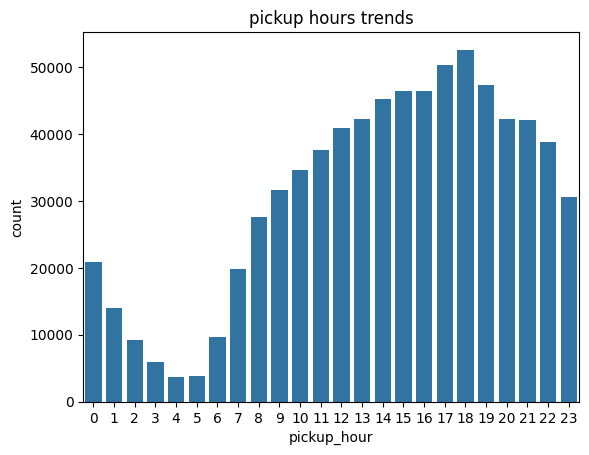

In [43]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour']=df['tpep_pickup_datetime'].dt.hour

sns.countplot(data=df,x= 'pickup_hour')
plt.title('pickup hours trends')
plt.show()

# Analyses shows that most taxi rides occur between 5pm to 7 pm , this is the time when people coming home from office.

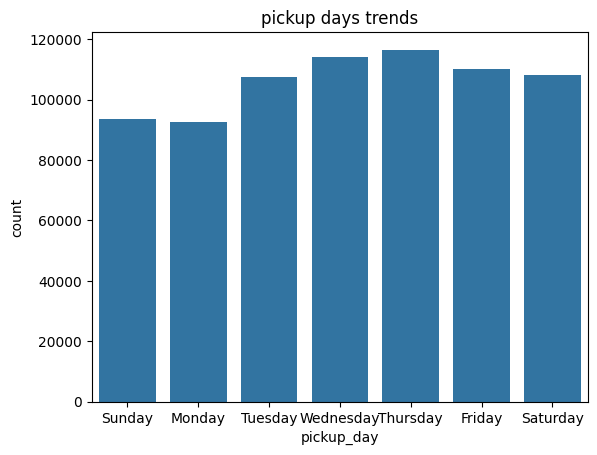

In [44]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

sns.countplot(data=df ,x='pickup_day')
plt.title('pickup days trends')
plt.show()
# analyses shows that there is not much differece in different days.


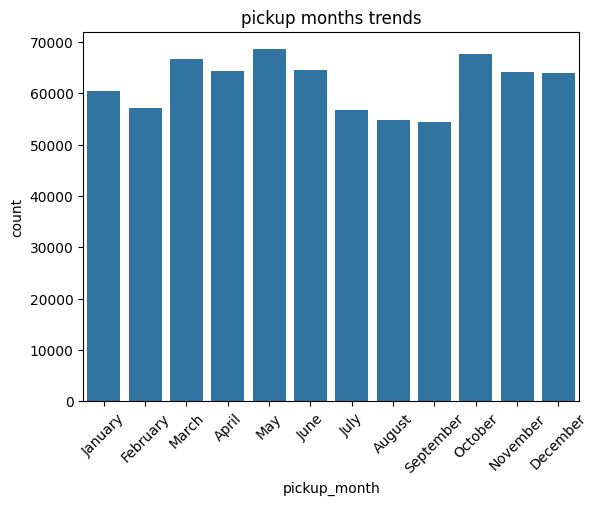

In [45]:
# Show the monthly trends in pickups

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
month_order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df,x='pickup_month',order=month_order)
plt.title('pickup months trends')
plt.xticks(rotation=45)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

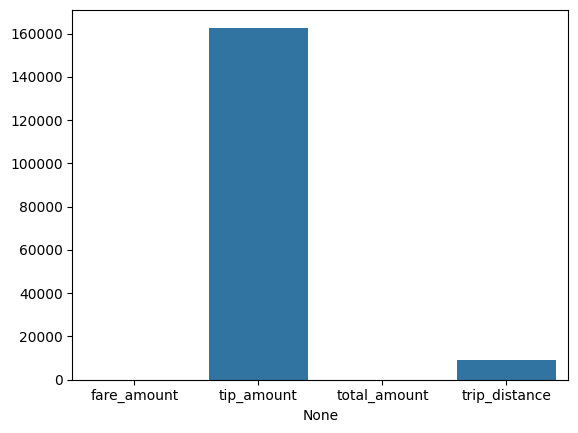

In [46]:
# Analyse the above parameters
df.describe()
# it is showing that above columns have zero values. let's visualize them.
zero_values = df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].apply(lambda x :(x==0).sum())
zero_values
sns.barplot(x=zero_values.index,y=zero_values.values)
plt.show()
# tip_amount and trip_distance have zero values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [47]:
# Create a df with non zero entries for the selected parameters.

df_filtered = df[(df['tip_amount']>0) & (df['trip_distance']>0)].copy()
df_filtered.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,576690.000000,576690,576690,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000,576690.000000
mean,1.745300,2023-07-01 20:51:18.322050,2023-07-01 21:08:06.782283,1.370646,3.411798,1.057586,166.847826,165.927178,1.000064,19.320518,1.680403,0.497172,4.569341,0.582679,0.999695,29.521411,2.373715,0.008198,14.426290
min,1.000000,2023-01-01 00:02:19,2023-01-01 00:09:40,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.010000,0.000000,0.000000,4.510000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-01 11:09:50.750000,2023-04-01 11:28:39.750000,1.000000,1.100000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,2.380000,0.000000,1.000000,16.800000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-25 10:15:21,2023-06-25 10:27:57,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,3.400000,0.000000,1.000000,21.800000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-06 17:35:57.500000,2023-10-06 18:02:10.500000,1.000000,3.330000,1.000000,234.000000,236.000000,1.000000,21.200000,2.500000,0.500000,5.000000,0.000000,1.000000,31.080000,2.500000,0.000000,19.000000
max,2.000000,2023-12-31 23:53:18,2024-01-01 20:14:57,6.000000,187.350000,5.000000,265.000000,265.000000,4.000000,475.000000,14.250000,0.800000,100.000000,56.000000,1.000000,487.610000,2.500000,1.250000,23.000000
std,0.435693,NaN,NaN,0.865311,4.378964,0.313191,63.287984,69.218613,0.012282,17.065057,1.846855,0.037579,3.929810,2.116070,0.014725,22.504936,0.547509,0.100895,5.797774


In [48]:
# drop records where The distance might be 0 in cases where pickup and drop is in the same zone.

df_filtered.drop(df_filtered[(df_filtered['trip_distance']==0)&(df_filtered['PULocationID']==df_filtered['DOLocationID'])].index,inplace=True)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

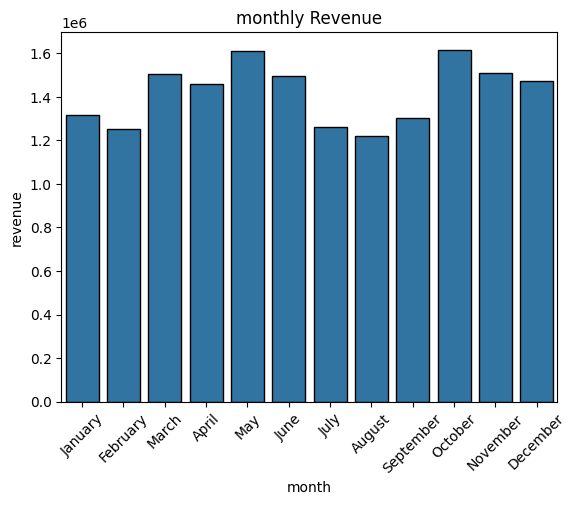

In [49]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_filtered.groupby('pickup_month')['total_amount'].sum()
monthly_revenue

sns.barplot(x= monthly_revenue.index , y=monthly_revenue.values,order=month_order,edgecolor='black')
plt.title('monthly Revenue')
plt.xlabel('month')
plt.ylabel('revenue')
plt.xticks(rotation=45)
plt.show()

# Analyses shows that highest revenue is gained in may and october months.


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

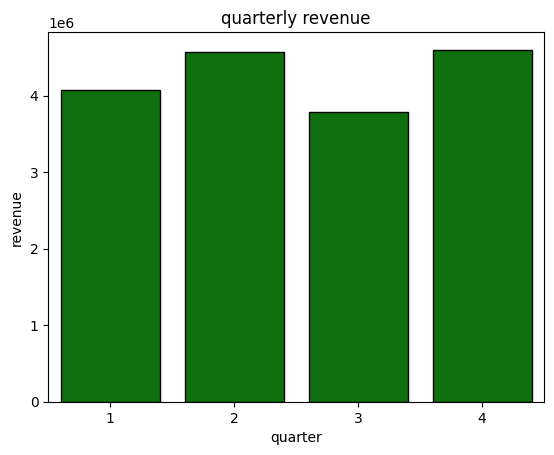

In [50]:
# Calculate proportion of each quarter
df_filtered['quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue= df_filtered.groupby('quarter')['total_amount'].sum()
quarterly_revenue

sns.barplot(x= quarterly_revenue.index , y=quarterly_revenue.values , color='green',edgecolor='black')
plt.title('quarterly revenue')
plt.xlabel('quarter')
plt.ylabel('revenue')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

correlation between trip_distance and fare_amount :0.9485690950241807


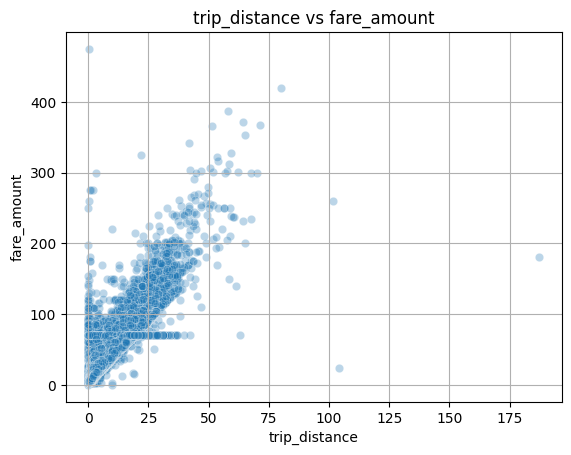

In [51]:
# Show how trip fare is affected by distance
df_filtered[df_filtered['trip_distance']==0]
# there is no records with trip_distance=0

correlation = df_filtered['trip_distance'].corr(df_filtered['fare_amount'])
print(f'correlation between trip_distance and fare_amount :{correlation}')
# strong positive correlation between trip_distance and fare_amount.

sns.scatterplot(data=df_filtered , x='trip_distance',y='fare_amount',alpha=0.3)
plt.title('trip_distance vs fare_amount')
plt.xlabel('trip_distance')
plt.ylabel('fare_amount')
plt.grid(True)
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

0.33163973019207305


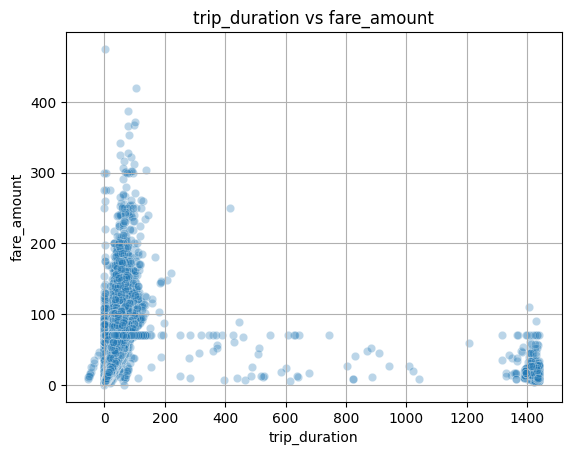

In [52]:
# Show relationship between fare and trip duration
df_filtered['trip_duration'] = (df_filtered['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

print(df_filtered['trip_duration'].corr(df_filtered['fare_amount']))
# there is a moderate level corr between trip_duration and fare_amount

sns.scatterplot(data=df_filtered , x='trip_duration',y='fare_amount',alpha=0.3)
plt.title('trip_duration vs fare_amount')
plt.xlabel('trip_duration')
plt.ylabel('fare_amount')
plt.grid(True)
plt.show()


0.03827699436060928


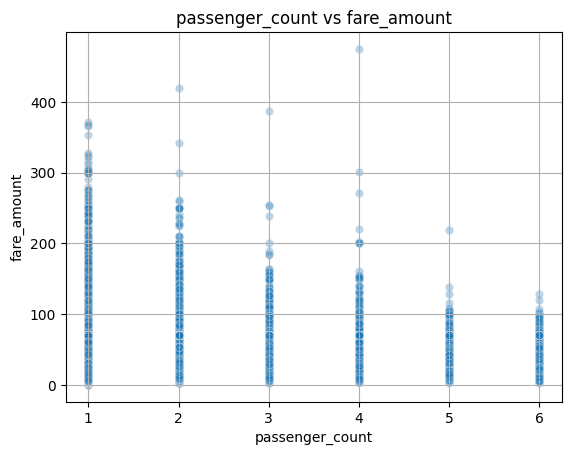

In [53]:
# Show relationship between fare and number of passengers
print(df_filtered['fare_amount'].corr(df_filtered['passenger_count']))
# there is a moderate level corr between fare and number of passengers

sns.scatterplot(data=df_filtered, x='passenger_count' , y='fare_amount',alpha=0.3)
plt.title('passenger_count vs fare_amount')
plt.xlabel('passenger_count')
plt.ylabel('fare_amount')
plt.grid(True)
plt.show()


0.8052084727137216


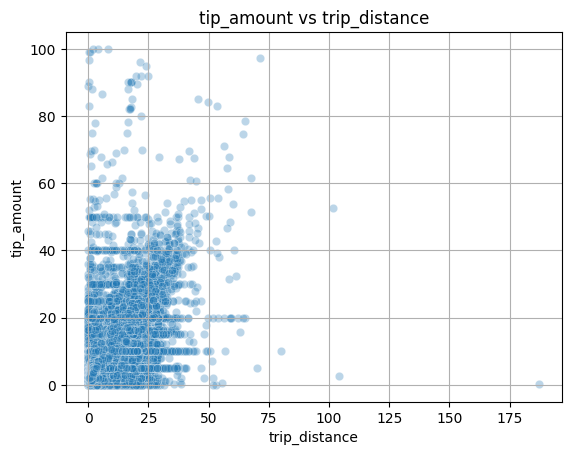

In [54]:
# Show relationship between tip and trip distance

print(df_filtered['tip_amount'].corr(df_filtered['trip_distance']))
# there is a high positive level corr between tip and trip distance

sns.scatterplot(data=df_filtered, x='trip_distance' , y='tip_amount',alpha=0.3)
plt.title('tip_amount vs trip_distance')
plt.xlabel('trip_distance')
plt.ylabel('tip_amount')
plt.grid(True)
plt.show()


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [55]:
df_filtered['payment_type'].value_counts()

,count
payment_type,
1,576671
2,8
4,7
3,4


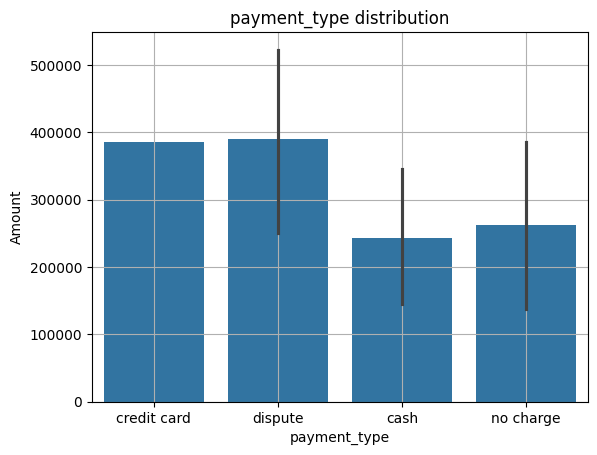

In [56]:
# Analyse the distribution of different payment types (payment_type).
payment_method = df_filtered['payment_type'].replace({1:'credit card',2:'cash',3:'no charge',4:'dispute'})
payment_counts = payment_method.value_counts()
payment_counts
sns.barplot(x= payment_method.values, y= payment_method.index)
plt.title('payment_type distribution')
plt.xlabel('payment_type')
plt.ylabel('Amount')
plt.grid(True)
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [57]:
!pip install geopandas


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [58]:
# import geopandas as gpd
import geopandas as gdp

# Read the shapefile using geopandas
zones = gdp.read_file('/content/drive/MyDrive/EDA_NYC_TAXI/taxi_zones/taxi_zones.shp')
# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

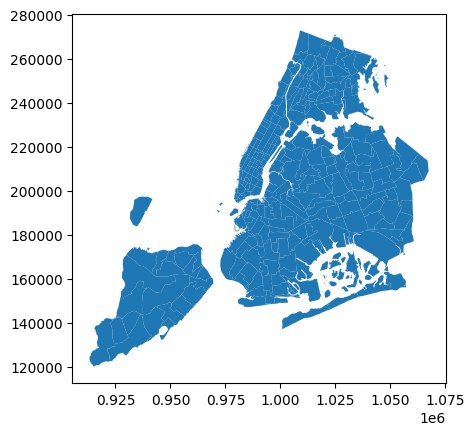

In [59]:
# print(zones.info())
print(zones.info())
# zones.plot()
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [60]:
# Merge zones and trip records using locationID and PULocationID
merged_data = pd.merge(df_filtered, zones, left_on='PULocationID', right_on='LocationID', how='left')
merged_data




,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_month,quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.9,...,January,1,5.083333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
1,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,246,37,1,34.5,...,January,1,33.616667,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."
2,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,79,164,1,11.4,...,January,1,10.516667,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
3,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,79,256,1,19.1,...,January,1,15.883333,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1.0,7.64,1.0,132,95,1,31.7,...,January,1,17.133333,132.0,0.245479,0.002038,JFK Airport,132.0,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576701,2,2023-12-31 20:43:49,2023-12-31 20:55:27,2.0,2.06,1.0,262,237,1,13.5,...,December,4,11.633333,262.0,0.049064,0.000122,Yorkville East,262.0,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."
576702,2,2023-12-31 21:19:50,2023-12-31 21:29:22,1.0,1.94,1.0,164,144,1,12.1,...,December,4,9.533333,164.0,0.035772,0.000056,Midtown South,164.0,Manhattan,"POLYGON ((988787.425 210315.593, 988662.868 21..."
576703,2,2023-12-31 21:21:53,2023-12-31 21:35:28,2.0,3.69,1.0,107,262,1,17.7,...,December,4,13.583333,107.0,0.038041,0.000075,Gramercy,107.0,Manhattan,"POLYGON ((989131.643 205749.904, 989084.531 20..."
576704,2,2023-12-31 23:53:18,2024-01-01 00:10:03,1.0,3.08,1.0,50,107,1,18.4,...,December,4,16.750000,50.0,0.055748,0.000173,Clinton West,50.0,Manhattan,"POLYGON ((985170.372 221087.389, 985817.17 220..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [61]:
# Group data by location and calculate the number of trips
total_trips = merged_data.groupby('LocationID').size().reset_index(name='total_trips')
total_trips


,LocationID,total_trips
0,1.0,17
1,4.0,556
2,6.0,1
3,7.0,95
4,9.0,2
...,...,...
191,258.0,2
192,260.0,42
193,261.0,2829
194,262.0,7749


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [62]:
# Merge trip counts back to the zones GeoDataFrame

zones = pd.merge(zones , total_trips, left_on='LocationID',right_on='LocationID', how='left')
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",17.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",556.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",NaN
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",42.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",2829.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",7749.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

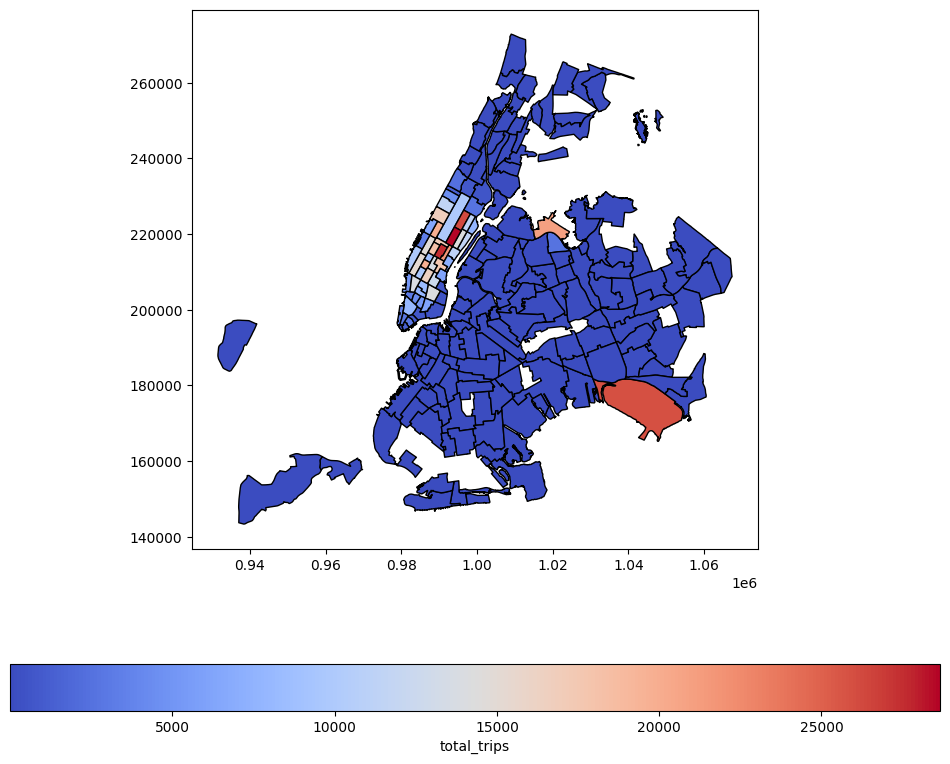

In [63]:
# Define figure and axis
fig, ax = plt.subplots(1,1,figsize=(12,10))

# Plot the map and display it
zones.plot(column='total_trips',ax=ax,legend=True,legend_kwds={'label': "total_trips", 'orientation': "horizontal"},cmap='coolwarm',edgecolor='black')
plt.show()



In [64]:
# can you try displaying the zones DF sorted by the number of trips?

zones.sort_values(by= 'total_trips', ascending=False,inplace=True)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",28651.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",27596.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",26240.0
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",25921.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",21646.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

**Summary of Findings from General Analysis:**

**Trends in taxi pickups**


**Hourly Trip Trends**

***Peak Usage Hours***: Most taxi rides occur between 5 PM and 7 PM, likely due to people commuting home from work during evening hours.

**Daily Trip Trends**

***Uniform Distribution***: The analysis shows minimal variation in taxi usage across different days of the week.

**Monthly Trip Trends**

***Consistent Volume***: Taxi usage remains fairly consistent across months.

***Slight Peaks***: Higher numbers of pickups are observed in May and October.


**Financial Analyses:**

**Monthly Revenue Trends**

***High Revenue Months***: Revenue is highest in May and October, likely aligning with the high trip volumes observed in these months.

**Quarterly Revenue Trends**

**Top Performing Quarters:**

Q2 (April–June) and

Q4 (October–December)
show the highest revenue generation throughout the year.

**Correlation Analysis**


- trip_distance vs fare_amount:	Strong Positive -	Longer trips naturally result in higher fare.

- trip_duration vs fare_amount:	Moderate Positive	Trips that last longer tend to cost more.

- passenger_count vs fare_amount	Moderate Positive	Fares slightly increase with more passengers.

- tip_amount vs trip_distance	High Positive	Longer trips tend to yield higher tips.

**Busiest Taxi Zones (Top 5)**


These zones consistently show highest taxi activity:

1.Upper East Side South

2.Midtown Center

3.Upper East Side North

4.JFK Airport

5.Midtown East


You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [65]:
# Find routes which have the slowest speeds at different times of the day
merged_data['speed'] = merged_data['trip_distance']/merged_data['trip_duration']

slowest_routes = merged_data.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(avg_speed=('speed','mean'),avg_time=('trip_duration','mean')).reset_index()
slowest_routes = slowest_routes[slowest_routes['avg_speed']>0]
slowest_routes.sort_values(by='avg_speed',ascending=True,inplace=True)
slowest_routes.head()

,PULocationID,DOLocationID,pickup_hour,avg_speed,avg_time
10103,70,138,6,0.001429,1042.566667
43533,161,238,7,0.001963,1395.500000
37827,144,217,16,0.002093,1419.233333
5888,48,184,1,0.002132,65.666667
53015,193,193,11,0.002500,4.000000


How does identifying high-traffic, high-demand routes help us?

Answer: Efficient routing: Drivers can focus on high-demand routes, reducing empty miles and fuel costs.

Higher earnings: More trips in less time means increased revenue for both drivers and the company.

Better customer service: Shorter wait times and faster pickups along busy routes.

Targeted promotions: Offer discounts or deals on less popular routes to balance demand.

Strategic planning: Helps decide where to increase cab availability during peak hours on these routes.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [66]:
busiest_hour = merged_data.pickup_hour.value_counts().sort_values(ascending=False).head()
busiest_hour

,count
pickup_hour,
18,42060
17,39588
19,37867
16,35476
15,34999


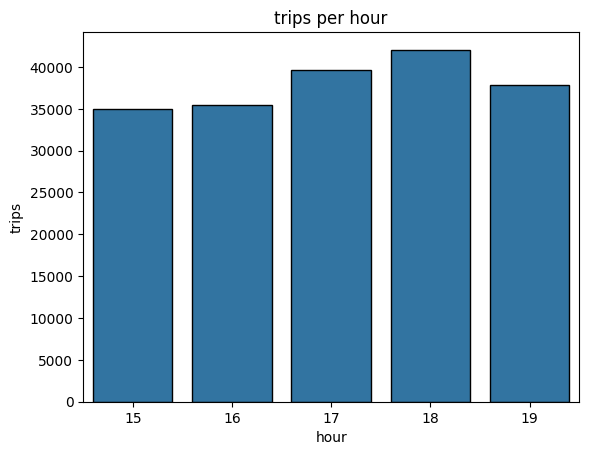

In [67]:
# Visualise the number of trips per hour and find the busiest hour

sns.barplot(x=busiest_hour.index,y=busiest_hour.values ,edgecolor='black')
plt.title('trips per hour')
plt.xlabel('hour')
plt.ylabel('trips')
plt.show()



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [68]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =0.02
scaledup_busiest_hour = busiest_hour * sample_fraction
scaledup_busiest_hour.sort_values(ascending=False).reset_index(name='number_of_trips').head()




,pickup_hour,number_of_trips
0,18,841.20
1,17,791.76
2,19,757.34
3,16,709.52
4,15,699.98


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

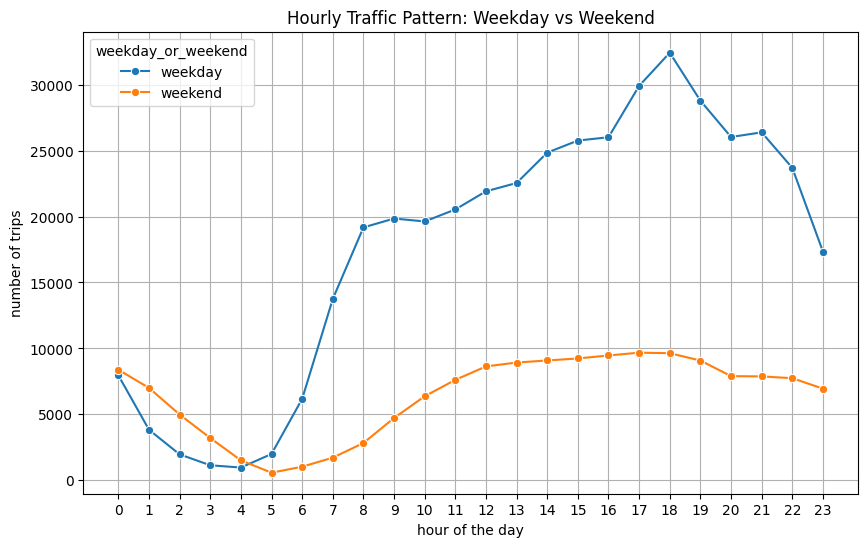

In [69]:
# Compare traffic trends for the week days and weekends
merged_data['weekday_or_weekend'] = merged_data['pickup_day'].apply({lambda x : 'weekend' if x in ['Saturday','Sunday'] else 'weekday'})
merged_data['weekday_or_weekend'].value_counts()


# now we will group data:
hourly_traffic_as_day =merged_data.groupby(['weekday_or_weekend', 'pickup_hour']).size().reset_index(name='hourly_traffic')
hourly_traffic_as_day


# let's visualize it
plt.figure(figsize=(10,6))
sns.lineplot(data=hourly_traffic_as_day,x='pickup_hour',y='hourly_traffic',hue='weekday_or_weekend',marker='o',linewidth=1.5,errorbar=None)
plt.title('Hourly Traffic Pattern: Weekday vs Weekend')
plt.xlabel('hour of the day')
plt.ylabel('number of trips')
plt.grid(True)
plt.xticks(range(24))
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?     


Answer: Better resource allocation: Drivers can be positioned in high-demand zones during busy hours to maximize trips.

Reduced idle time: Knowing quiet hours allows for planned breaks, maintenance, or offering discounts to attract riders.

Increased revenue: Matching fleet availability to peak periods ensures more completed trips and higher earnings.

Improved customer service: Shorter wait times for riders during busy hours by ensuring enough cabs are available.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [70]:
# Find top 10 pickup and dropoff zones
merged_data['dropoff_hour'] = merged_data['tpep_dropoff_datetime'].dt.hour
hourly_pickup_zone =merged_data.groupby(['pickup_hour','zone']).size().reset_index(name='hourly_pickup_count')

top10_pickup_zone = hourly_pickup_zone.sort_values(by='hourly_pickup_count',ascending=False).head(10)
top10_pickup_zone



,pickup_hour,zone,hourly_pickup_count
1886,18,Midtown Center,2518
1776,17,Midtown Center,2433
1810,17,Upper East Side South,2185
1588,15,Upper East Side North,2181
1992,19,Midtown Center,2176
1918,18,Upper East Side South,2151
1482,14,Upper East Side South,2148
1589,15,Upper East Side South,2135
1696,16,Upper East Side South,2086
1664,16,Midtown Center,2079


In [71]:




hourly_dropoff_zone = merged_data.groupby(['dropoff_hour','zone']).size().reset_index(name='hourly_dropoff_count')
top10_dropoff_zone = hourly_dropoff_zone.sort_values(by='hourly_dropoff_count',ascending=False).head(10)
top10_dropoff_zone


,dropoff_hour,zone,hourly_dropoff_count
1870,18,Midtown Center,2643
1981,19,Midtown Center,2334
1759,17,Midtown Center,2325
1906,18,Upper East Side South,2243
1792,17,Upper East Side South,2198
1577,15,Upper East Side North,2166
1578,15,Upper East Side South,2147
1467,14,Upper East Side South,2109
1685,16,Upper East Side South,2094
1905,18,Upper East Side North,2094


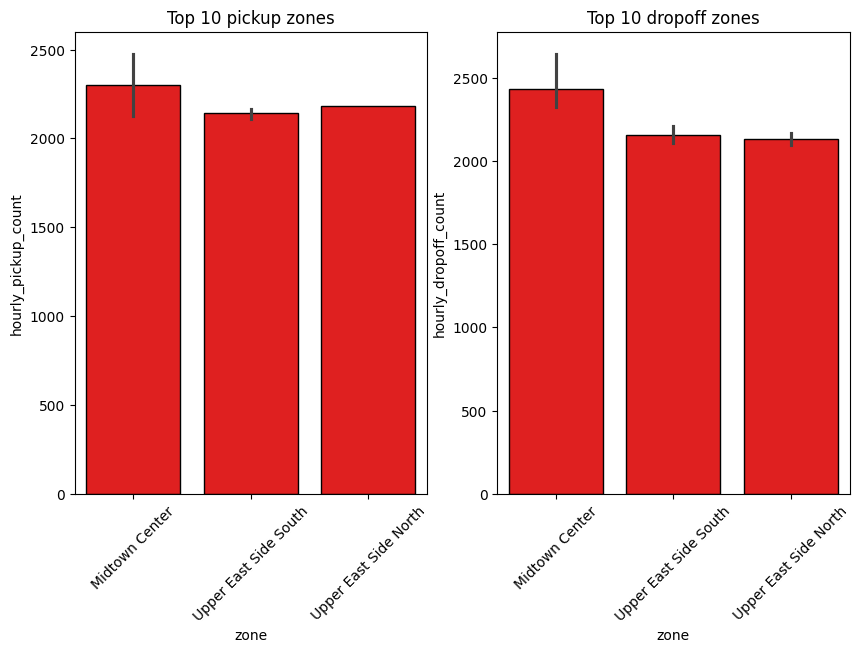

In [72]:
# let's visualize them for better understanding
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.barplot(data=top10_pickup_zone,x='zone',y='hourly_pickup_count',color='red',edgecolor='black')
plt.title('Top 10 pickup zones')
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.barplot(data=top10_dropoff_zone,x='zone',y='hourly_dropoff_count',color='red',edgecolor='black')
plt.title('Top 10 dropoff zones')
plt.xticks(rotation=45)
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

Top 10 Pickup/Dropoff Ratios:
                      zone  pickup_dropoff_ratio
0            Alphabet City                   1.0
1  Arrochar/Fort Wadsworth                   1.0
2                  Astoria                   1.0
3               Auburndale                   1.0
4             Baisley Park                   1.0
5               Bath Beach                   1.0
6             Battery Park                   1.0
7        Battery Park City                   1.0
8                Bay Ridge                   1.0
9                  Bedford                   1.0

Bottom 10 Pickup/Dropoff Ratios:
                      zone  pickup_dropoff_ratio
0            Alphabet City                   1.0
1  Arrochar/Fort Wadsworth                   1.0
2                  Astoria                   1.0
3               Auburndale                   1.0
4             Baisley Park                   1.0
5               Bath Beach                   1.0
6             Battery Park                   1.0
7    

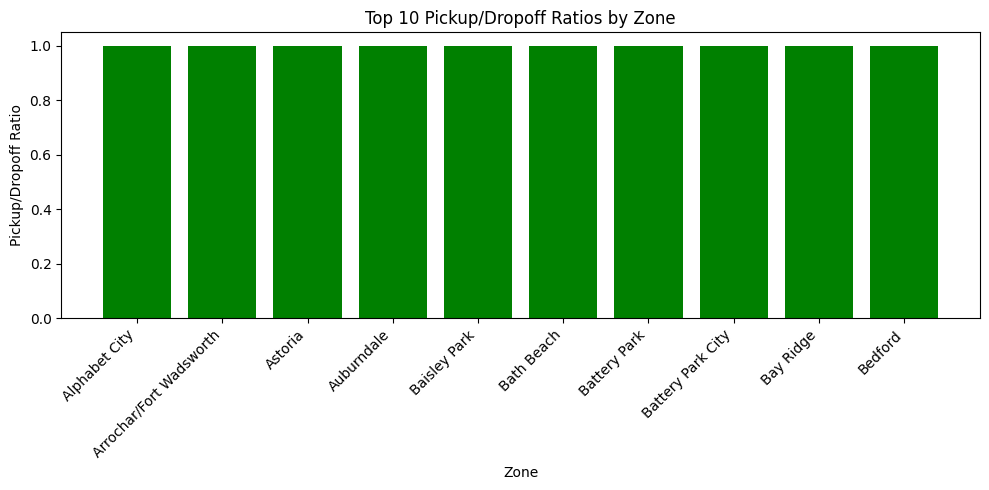

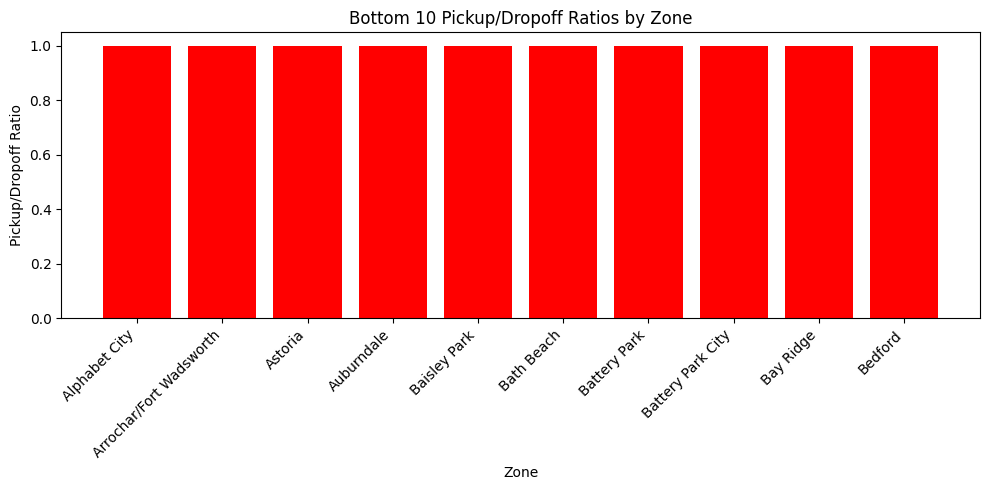

In [73]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



# Count pickups per zone
pickup_counts = merged_data.groupby('zone')['PULocationID'].count().reset_index(name='pickup_count')

# Count dropoffs per zone
dropoff_counts = merged_data.groupby('zone')['DOLocationID'].count().reset_index(name='dropoff_count')

# Merge pickup and dropoff counts
zone_counts = pd.merge(pickup_counts, dropoff_counts, on='zone')

# Calculate pickup/dropoff ratio
zone_counts['pickup_dropoff_ratio'] = zone_counts['pickup_count'] / zone_counts['dropoff_count']

# Sort for top 10 and bottom 10
top_10 = zone_counts.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
bottom_10 = zone_counts.sort_values(by='pickup_dropoff_ratio').head(10)

# Display results
print("Top 10 Pickup/Dropoff Ratios:")
print(top_10[['zone', 'pickup_dropoff_ratio']])

print("\nBottom 10 Pickup/Dropoff Ratios:")
print(bottom_10[['zone', 'pickup_dropoff_ratio']])


# Plot top 10 pickup/dropoff ratio zones
plt.figure(figsize=(10, 5))
plt.bar(top_10['zone'], top_10['pickup_dropoff_ratio'], color='green')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Pickup/Dropoff Ratios by Zone')
plt.xlabel('Zone')
plt.ylabel('Pickup/Dropoff Ratio')
plt.tight_layout()
plt.show()

# Plot bottom 10 pickup/dropoff ratio zones
plt.figure(figsize=(10, 5))
plt.bar(bottom_10['zone'], bottom_10['pickup_dropoff_ratio'], color='red')
plt.xticks(rotation=45, ha='right')
plt.title('Bottom 10 Pickup/Dropoff Ratios by Zone')
plt.xlabel('Zone')
plt.ylabel('Pickup/Dropoff Ratio')
plt.tight_layout()
plt.show()





**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [74]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones


#  find the night hours data first by pickup hour
night_pickup_hours = merged_data[(merged_data['pickup_hour'] >= 23) | (merged_data['pickup_hour'] <= 5)]

# find night dropoff hours data
night_dropoff_hours = merged_data[(merged_data['dropoff_hour'] >= 23) | (merged_data['dropoff_hour'] <= 5)]

# we will groupby data pickup hours with zone to find night pickup zone
night_pickup_zone =night_pickup_hours.groupby('zone').size().reset_index(name='night_pickup_count')
top10_night_pickup_zone = night_pickup_zone.sort_values(by='night_pickup_count',ascending=False).head(10)

# we will groupby data dropoff hours with zone to find night dropoff  zone
night_dropoff_zone = night_dropoff_hours.groupby('zone').size().reset_index(name='night_dropoff_count')
top10_night_dropoff_zone = night_dropoff_zone.sort_values(by='night_dropoff_count',ascending=False).head(10)

                             zone  night_pickup_count
39                   East Village                5218
135                  West Village                4313
61                    JFK Airport                3892
75                Lower East Side                3326
23                   Clinton East                3219
56        Greenwich Village South                2847
122     Times Sq/Theatre District                2478
99   Penn Station/Madison Sq West                2105
87                  Midtown South                1974
67              LaGuardia Airport                1936


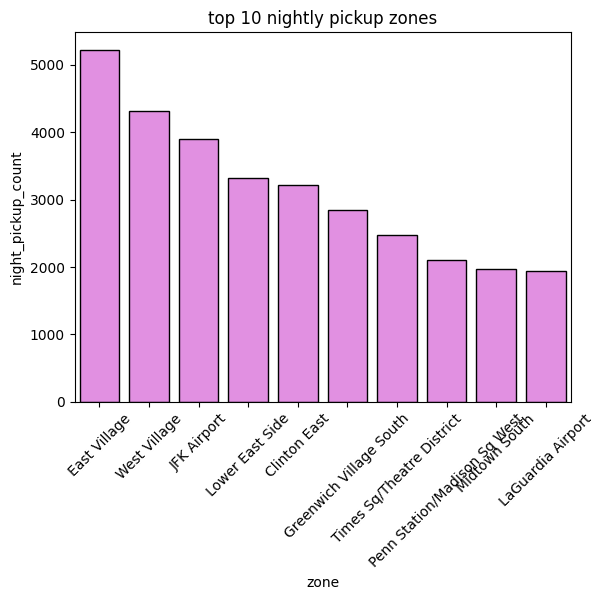

In [75]:
print(top10_night_pickup_zone)
sns.barplot(data=top10_night_pickup_zone,x='zone',y='night_pickup_count',color='violet',edgecolor='black')
plt.title('top 10 nightly pickup zones')
plt.xticks(rotation=45)
plt.show()


                             zone  night_dropoff_count
40                   East Village                 5505
62                    JFK Airport                 4900
138                  West Village                 4627
23                   Clinton East                 3465
77                Lower East Side                 3462
57        Greenwich Village South                 3041
125     Times Sq/Theatre District                 2753
69              LaGuardia Airport                 2332
101  Penn Station/Madison Sq West                 2313
89                  Midtown South                 2140


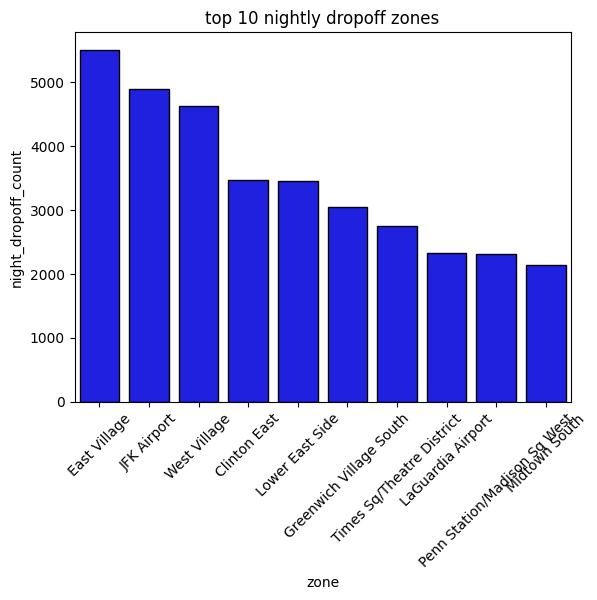

In [76]:
print(top10_night_dropoff_zone)

sns.barplot(data=top10_night_dropoff_zone,x='zone',y='night_dropoff_count',color='blue',edgecolor='black')
plt.title('top 10 nightly dropoff zones')
plt.xticks(rotation=45)
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [77]:
# Filter for night hours (11 PM to 5 AM)

night_hours = merged_data[(merged_data['pickup_hour'] >= 23) | (merged_data['pickup_hour'] <= 5)]
day_hours = merged_data[(merged_data['pickup_hour'] >= 6) & (merged_data['pickup_hour'] <= 22)]

night_hours_revenue = night_hours['total_amount'].sum()
day_hours_revenue = day_hours['total_amount'].sum()

print("Night Hours Revenue:", night_hours_revenue)
print("Day Hours Revenue:", day_hours_revenue)

Night Hours Revenue: 2028804.7400000002
Day Hours Revenue: 14997244.240000002


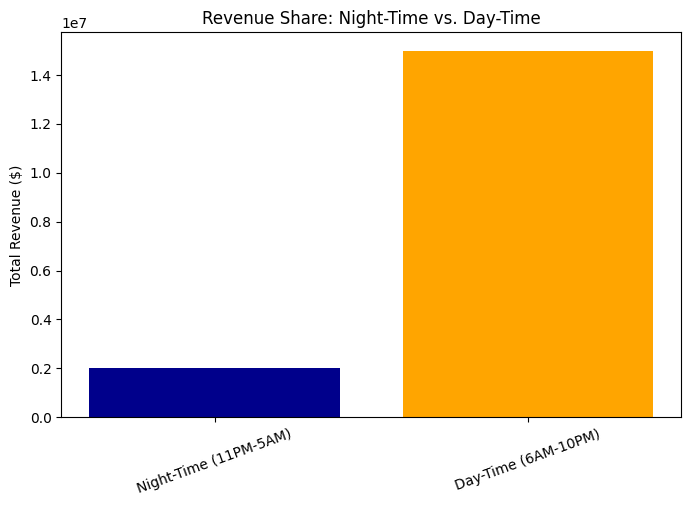

In [78]:
labels = ['Night-Time (11PM-5AM)', 'Day-Time (6AM-10PM)']
revenues = [night_hours_revenue, day_hours_revenue]

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, revenues, color=['darkblue', 'orange'])
plt.ylabel("Total Revenue ($)")
plt.title("Revenue Share: Night-Time vs. Day-Time")
plt.xticks(rotation=20)
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [79]:
# Analyse the fare per mile per passenger for different passenger counts

merged_data['fare_per_mile'] = merged_data['total_amount'] / merged_data['trip_distance']
fare_per_mile_per_passenger = merged_data.groupby('passenger_count')['fare_per_mile'].mean()
fare_per_mile_per_passenger


,fare_per_mile
passenger_count,
1.0,15.243483
2.0,16.964667
3.0,17.557881
4.0,19.770910
5.0,13.039111
6.0,12.933577


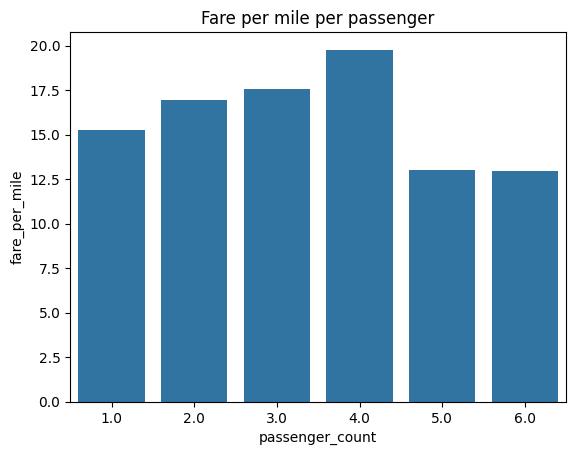

In [80]:
# let's visualize it

sns.barplot(data=fare_per_mile_per_passenger.reset_index(),x='passenger_count',y='fare_per_mile')
plt.title('Fare per mile per passenger')
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

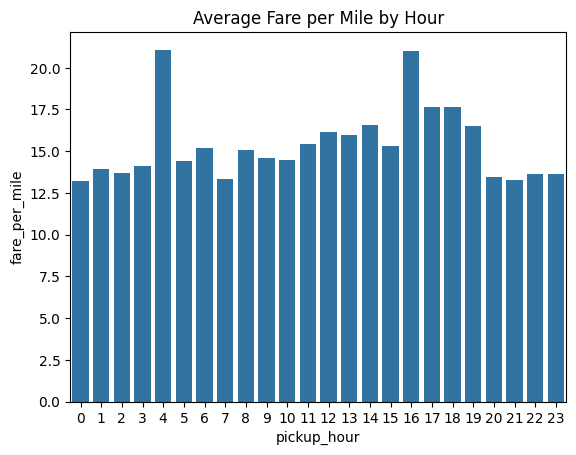

/tmp/ipython-input-3255160255.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_fare_per_mile_by_day.reset_index(),x='pickup_day',y='fare_per_mile', palette="viridis")


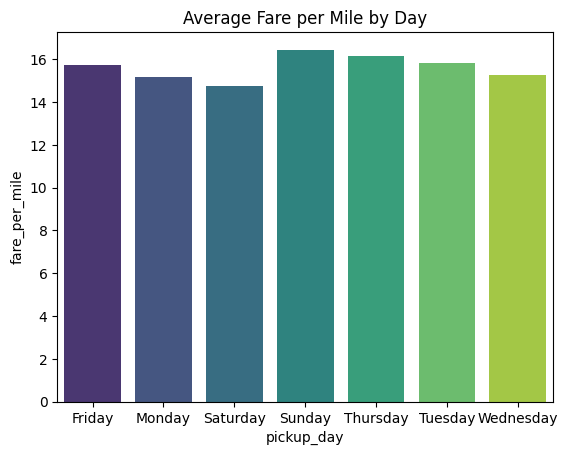

In [81]:
# Compare the average fare per mile for different days and for different times of the day

avg_fare_per_mile_by_hour = merged_data.groupby('pickup_hour')['fare_per_mile'].mean()
avg_fare_per_mile_by_day = merged_data.groupby('pickup_day')['fare_per_mile'].mean()

# plot fare per mile by hour
sns.barplot(data=avg_fare_per_mile_by_hour.reset_index(),x='pickup_hour',y='fare_per_mile')
plt.title('Average Fare per Mile by Hour')
plt.xticks(range(24))
plt.show()

# plot avg. fare per mile by days of the week

sns.barplot(data=avg_fare_per_mile_by_day.reset_index(),x='pickup_day',y='fare_per_mile', palette="viridis")
plt.title('Average Fare per Mile by Day')
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

    VendorID  pickup_hour  avg_vendor_fare_per_hour
0          1            0                 11.973459
1          1            1                 11.866825
2          1            2                 12.788748
3          1            3                 11.326020
4          1            4                 13.111202
5          1            5                 12.729190
6          1            6                 10.609747
7          1            7                 11.723682
8          1            8                 12.945008
9          1            9                 13.290006
10         1           10                 13.470109
11         1           11                 14.007138
12         1           12                 14.106179
13         1           13                 13.842092
14         1           14                 13.929996
15         1           15                 14.044280
16         1           16                 15.635935
17         1           17                 15.310463
18         1

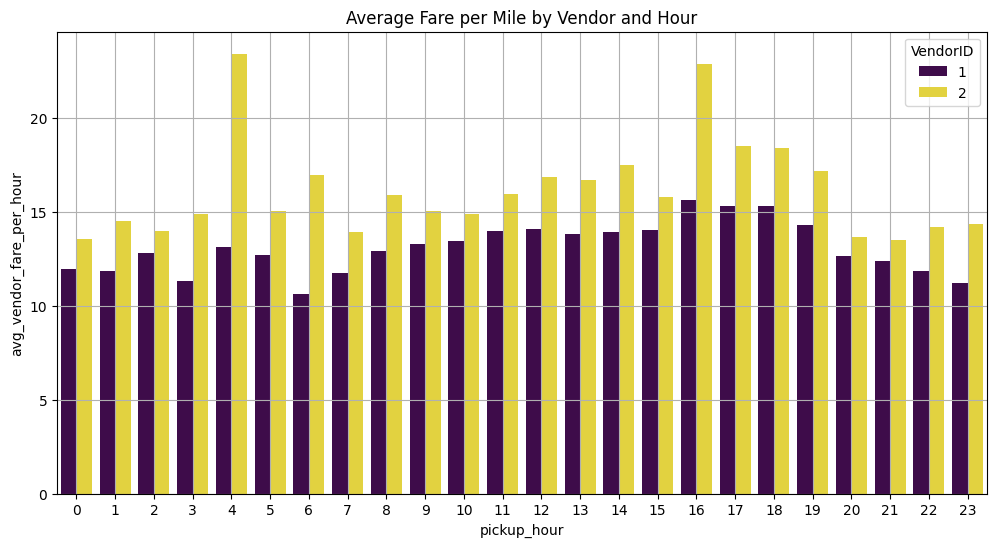

In [82]:
# Compare fare per mile for different vendors

vendor_fare_analyses = merged_data.groupby(['VendorID','pickup_hour'])['fare_per_mile'].mean().reset_index(name='avg_vendor_fare_per_hour')
print(vendor_fare_analyses)


# visualize it.
plt.figure(figsize=(12,6))
sns.barplot(data=vendor_fare_analyses,x='pickup_hour',y='avg_vendor_fare_per_hour',hue='VendorID', palette="viridis")
plt.title('Average Fare per Mile by Vendor and Hour')
plt.grid(True)
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


   VendorID distance_tier  avg_tiered_fare
0         1     0-2 miles        17.294758
1         1     2-5 miles         9.513453
2         1      >5 miles         6.403190
3         2     0-2 miles        22.850388
4         2     2-5 miles         9.776655
5         2      >5 miles         6.441863


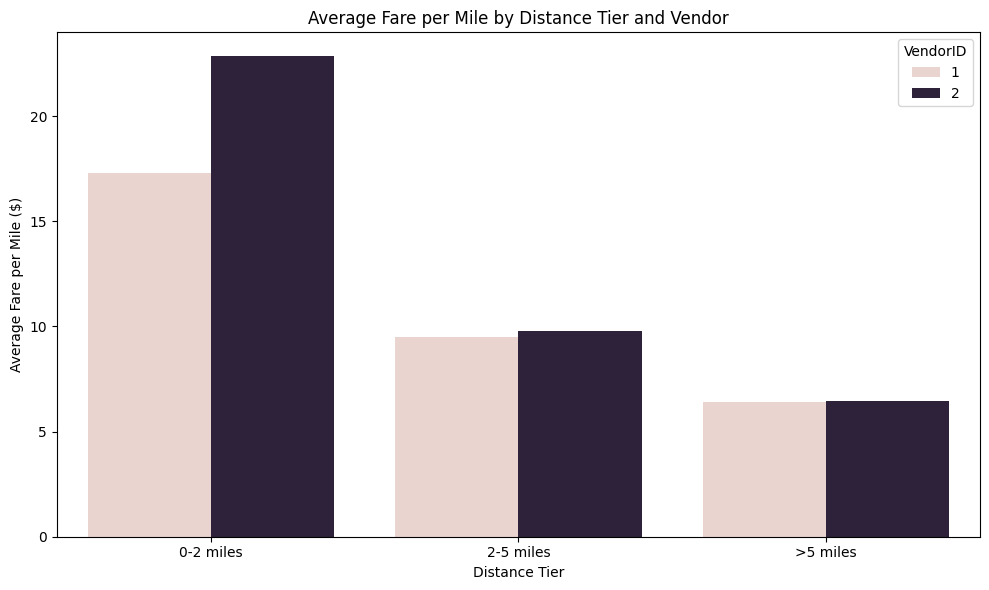

In [83]:
# Defining distance tiers
merged_data['distance_tier'] = pd.cut(merged_data['trip_distance'], bins=[0, 2, 5 ,float('inf')], labels=['0-2 miles' , '2-5 miles', '>5 miles' ])
tiered_fare_analysis = (merged_data
                        .groupby(['VendorID', 'distance_tier'],observed=True)['fare_per_mile']
                        .mean()
                        .reset_index(name='avg_tiered_fare'))
print(tiered_fare_analysis)



plt.figure(figsize=(10, 6))
sns.barplot(data=tiered_fare_analysis, x='distance_tier', y='avg_tiered_fare', hue='VendorID')
plt.title('Average Fare per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile ($)')
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

distance_tier
0-2 miles    15.622201
2-5 miles    15.165272
>5 miles     15.076267
Name: tip_percentage, dtype: float64
passenger_count
1.0    15.398960
2.0    15.396013
3.0    15.431815
4.0    15.517830
5.0    15.443833
6.0    15.494964
Name: tip_percentage, dtype: float64
pickup_hour
0     15.133644
1     15.210947
2     15.137828
3     15.206452
4     15.337721
5     15.104015
6     15.178154
7     15.189235
8     15.278918
9     15.477024
10    15.641058
11    15.690284
12    15.697880
13    15.630701
14    15.644904
15    15.526263
16    15.332756
17    15.295187
18    15.255794
19    15.218395
20    15.367381
21    15.377760
22    15.359834
23    15.258345
Name: tip_percentage, dtype: float64


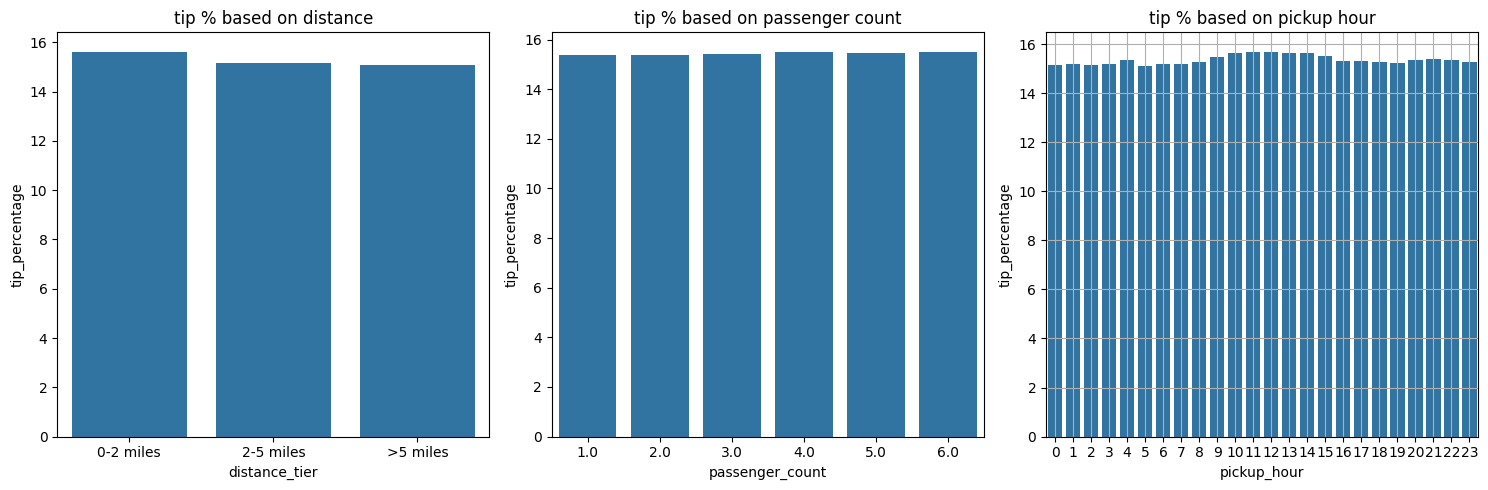

In [84]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
merged_data['tip_percentage'] = merged_data['tip_amount'] / merged_data['total_amount']*100
tip_by_distance = merged_data.groupby('distance_tier',observed=True)['tip_percentage'].mean()
print(tip_by_distance)


# tip % based on pasenger_counts
tip_by_passenger_count = merged_data.groupby('passenger_count',observed=True)['tip_percentage'].mean()
print(tip_by_passenger_count)

# tip% based on pickup hour
tip_by_pickup_hour = merged_data.groupby('pickup_hour',observed=True)['tip_percentage'].mean()
print(tip_by_pickup_hour)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.barplot(data=tip_by_distance.reset_index(),x='distance_tier',y='tip_percentage')
plt.title('tip % based on distance')
plt.subplot(1,3,2)
sns.barplot(data=tip_by_passenger_count.reset_index(),x='passenger_count',y='tip_percentage')
plt.title('tip % based on passenger count')
plt.subplot(1,3,3)
sns.barplot(data=tip_by_pickup_hour.reset_index(),x='pickup_hour',y='tip_percentage')
plt.title('tip % based on pickup hour')
plt.tight_layout()
plt.grid(True)
plt.xticks(range(24))
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [85]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip_df = merged_data[merged_data['tip_percentage']<10]
high_tip_df = merged_data[merged_data['tip_percentage']>25]

# average trip distance
print("Avg Trip Distance:")
print("Low Tip:", low_tip_df['trip_distance'].mean())
print("High Tip:", high_tip_df['trip_distance'].mean())

# pasenger count
print("Avg Passenger Count:")
print("Low Tip:", low_tip_df['passenger_count'].mean())
print("High Tip:", high_tip_df['passenger_count'].mean())

# pickup hour
print("Avg Pickup Hour:")
print("Low Tip:", low_tip_df['pickup_hour'].mean())
print("High Tip:", high_tip_df['pickup_hour'].mean())


# payment type
print("Payment Type Distribution:")
print("Low Tip:\n", low_tip_df['payment_type'].value_counts(normalize=True) * 100)
print("\nHigh Tip:\n", high_tip_df['payment_type'].value_counts(normalize=True) * 100)

# interpretation =
# Trip Distance -	Longer trips get lower tips, likely due to total fare size
# Passenger Count -	No meaningful difference
# Pickup Hour -	Slightly earlier pickups tip better, but not significantly
# Payment Type -	Credit card usage aligns with higher tips; cash may lead to underreported tips


Avg Trip Distance:
Low Tip: 3.574950089400954
High Tip: 2.289038776624795
Avg Passenger Count:
Low Tip: 1.356443381369078
High Tip: 1.38203167667941
Avg Pickup Hour:
Low Tip: 14.300363524410605
High Tip: 13.48170398689241
Payment Type Distribution:
Low Tip:
 payment_type
1    99.994079
4     0.002368
3     0.002368
2     0.001184
Name: proportion, dtype: float64

High Tip:
 payment_type
1    100.0
Name: proportion, dtype: float64


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

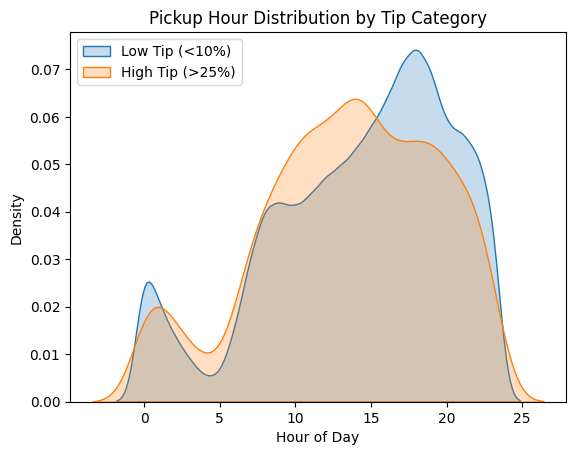

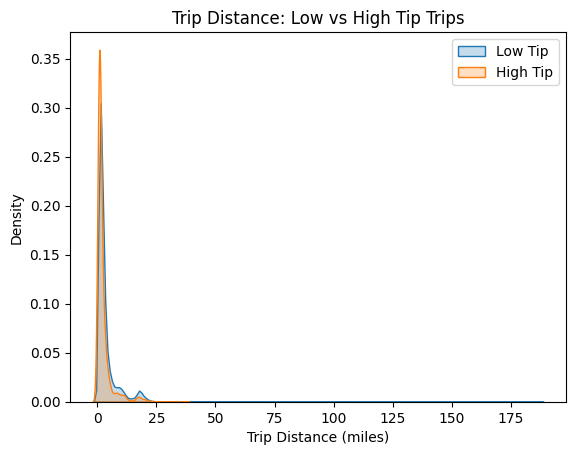

In [86]:
# Tip Percentage by Pickup Hour
sns.kdeplot(low_tip_df['pickup_hour'], label='Low Tip (<10%)', fill=True)
sns.kdeplot(high_tip_df['pickup_hour'], label='High Tip (>25%)', fill=True)
plt.title("Pickup Hour Distribution by Tip Category")
plt.xlabel("Hour of Day")
plt.legend()
plt.show()

# Trip distance comparison
sns.kdeplot(low_tip_df['trip_distance'], label='Low Tip', fill=True)
sns.kdeplot(high_tip_df['trip_distance'], label='High Tip', fill=True)
plt.title("Trip Distance: Low vs High Tip Trips")
plt.xlabel("Trip Distance (miles)")
plt.legend()
plt.show()


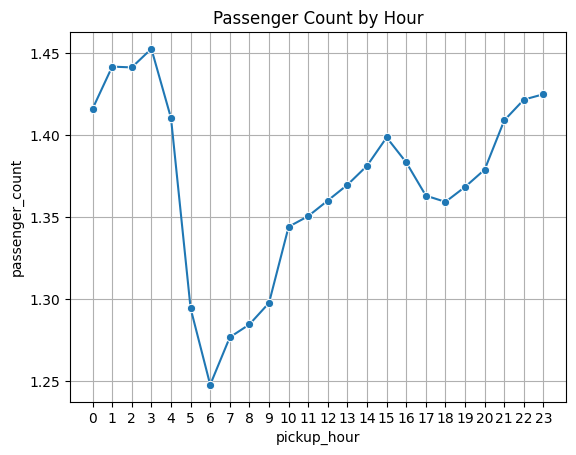

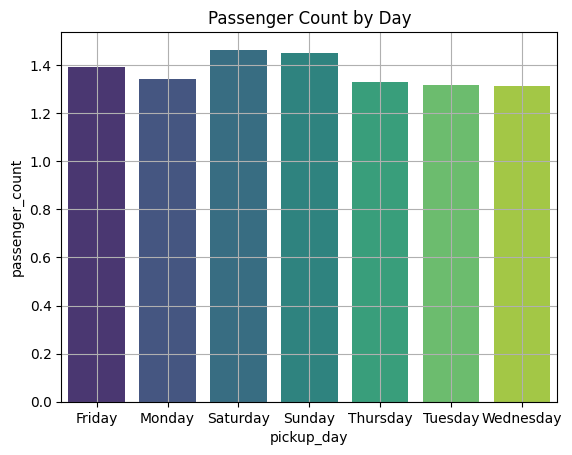

In [87]:
# See how passenger count varies across hours and days

# passenger count by hour

passenger_count_by_hour = merged_data.groupby('pickup_hour')['passenger_count'].mean()
passenger_count_by_hour

sns.lineplot(data=passenger_count_by_hour.reset_index(),x='pickup_hour',y='passenger_count',marker='o')
plt.title('Passenger Count by Hour')
plt.xticks(range(24))
plt.grid(True)
plt.show()

# passenger count by days
passenger_count_by_day = merged_data.groupby('pickup_day')['passenger_count'].mean()
passenger_count_by_day

sns.barplot(data=passenger_count_by_day.reset_index(),x='pickup_day',y='passenger_count',hue='pickup_day', label=False ,palette="viridis")
plt.title('Passenger Count by Day')
plt.grid(True)
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

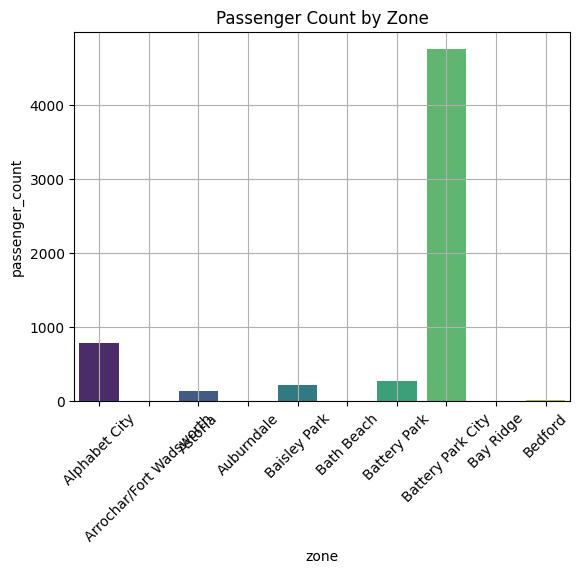

In [88]:
# How does passenger count vary across zones

passenger_count_by_zones = merged_data.groupby('zone')['passenger_count'].sum()
passenger_count_by_zones.sort_values(ascending=False).head()

sns.barplot(data=passenger_count_by_zones.reset_index().head(10),x='zone',y='passenger_count',hue='zone',palette="viridis")
plt.title('Passenger Count by Zone')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



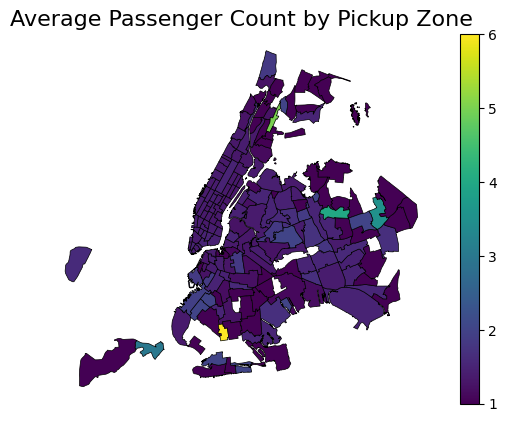

In [103]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
# Step 1: Group by zone to get total passengers and trip counts
zone_stats = (
    merged_data.groupby('zone')['passenger_count']
    .agg(total_passengers='sum', trip_count='count')
    .reset_index()
)

# Step 2: Calculate average passenger count
zone_stats['avg_passenger_count'] = (
    zone_stats['total_passengers'] / zone_stats['trip_count']
)

# Step 3: Merge back into zones_with_trips
zones_with_trips = zones.merge(
    zone_stats[['zone', 'avg_passenger_count']],
    on='zone',
    how='left'
)

# Plot the zones coloured by average passenger count

zones_with_trips.plot(
    column='avg_passenger_count',      # column to colour by
    cmap='viridis',                    # colour map (you can try 'plasma', 'coolwarm', etc.)
    legend=True,                       # show legend
    edgecolor='black',                 # zone borders
    linewidth=0.5
)

plt.title("Average Passenger Count by Pickup Zone", fontsize=16)
plt.axis('off')  # hide axis
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

improvement_surcharge    100.00
mta_tax                   99.43
congestion_surcharge      94.95
extra                     63.50
airport_fee                0.66
dtype: float64


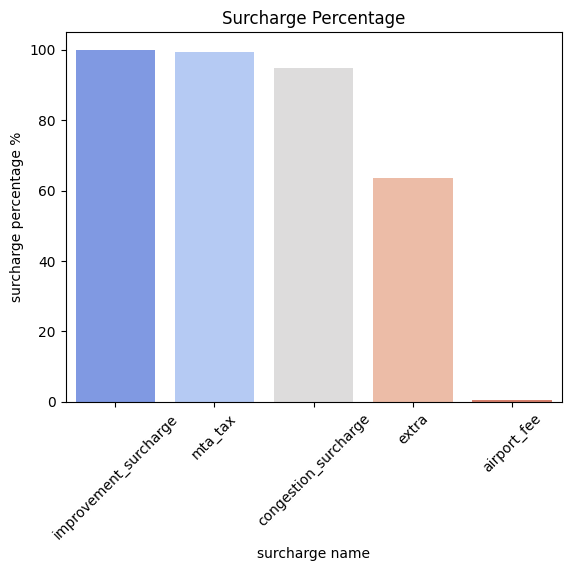

In [99]:
# How often is each surcharge applied?

# first create a list of all surcharges
surcharge = ['extra', 'mta_tax','improvement_surcharge','congestion_surcharge', 'airport_fee']

# we will sum the data to caclutating surcharge_counts
surcharge_counts = (merged_data[surcharge]>0).sum() # count non zero values
surcharge_percentage =surcharge_counts / len(merged_data) *100

#sort the values
surcharge_percentage = surcharge_percentage.sort_values(ascending=False).round(2)
print(surcharge_percentage)

# visualize it.
sns.barplot(x=surcharge_percentage.index , y= surcharge_percentage.values, palette='coolwarm',hue=surcharge_percentage.index ,legend=False)
plt.xlabel('surcharge name')
plt.ylabel('surcharge percentage %')
plt.title('Surcharge Percentage')
plt.xticks(rotation=45)
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

From the analysis, we saw that demand is highest during morning (7–10 AM) and evening (5–8 PM) rush hours on weekdays, mostly in busy business areas of Manhattan.
→ Tip: Keep more taxis ready in business zones in the morning and in residential areas in the evening to match where people are going.

On weekends, people travel more to tourist spots and nightlife areas, with demand peaking late at night.
→ Tip: Send more taxis to these areas during weekends and keep an eye on events for extra demand.

Airports always have steady demand.
→ Tip: Have a fixed rotation of drivers for airport trips so no one waits too long.

Short rides happen more inside the city, while long rides are mostly to/from airports and outer boroughs.
→ Tip: Assign city drivers for short trips and keep some drivers free for longer airport trips.

Some areas get fewer taxis during off-peak times.
→ Tip: Offer incentives for drivers to go to these places when it’s quiet, so passengers don’t have to wait too long and drivers avoid empty returns.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.


Weekday Mornings (7–10 AM): Position more cabs in residential areas so they can take passengers to business hubs.

Weekday Evenings (5–8 PM): Shift more cabs to business districts to handle office-to-home trips.

Weekends (Evening & Late Night): Place cabs near tourist attractions, shopping areas, and nightlife spots like downtown Manhattan.

Airport Zones: Keep a steady supply of cabs at JFK, LaGuardia, and Newark, especially during early mornings and late nights when flights are frequent.

Event Days: Increase cabs near stadiums, concert venues, and exhibition centers based on event schedules.

Low-Demand Zones: Rotate drivers into these areas during quiet hours so coverage is even across the city.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.


1. Passenger Count–Based Pricing

1–2 passengers (majority of trips): Keep fares competitive to maintain steady demand.

3–4 passengers (less common): Offer a flat group fare to encourage shared rides and increase occupancy.

2. Time-Based Adjustments

Peak hours (8–10 AM, 5–7 PM): Slightly raise fares (5–10%) to match high demand and limited supply.

Late night (11 PM–5 AM): Use night surcharge for driver incentive and safety coverage.

Midday off-peak (10 AM–3 PM): Give small discounts to boost usage and reduce idle time.

3. Trip Distance Strategy

Short trips (<2 miles): Keep base fare low to stay competitive; offer “short hop” promos in slow zones.

Medium trips (2–6 miles): Maintain standard rates as these have steady demand.

Long trips (>6 miles, esp. airport): Introduce flat rates (e.g., JFK–Manhattan, LaGuardia–Manhattan) to attract more long-distance riders.

4. Zone & Event-Based Pricing

High-demand zones (Midtown, Times Square, airports): Surge pricing during rush hours and events.

Low-demand zones: Offer targeted discounts to bring in more trips.

5. Competitive & Cost-Linked Adjustments

Monitor competitor pricing daily; adjust within ±5% to stay competitive.

Review operational costs monthly; tweak fares if fuel/maintenance costs rise.

